In [24]:
import os
import shutil
import json
import re
import matplotlib.pyplot as plt
from struct_eval_functions import *
from struct_plot_funcitons import *

### JSON to Text

In [25]:
def process_node(node):
    if 'raw_text' in node:
        return node['raw_text'].strip()

    if 'AND' in node:
        left_text = process_node(node['AND']['left'])
        right_text = process_node(node['AND']['right'])
        return combine_texts(left_text, right_text, '[AND]')

    if 'OR' in node:
        left_text = process_node(node['OR']['left'])
        right_text = process_node(node['OR']['right'])
        return combine_texts(left_text, right_text, '[OR]')

    if 'NOT' in node:
        left_text = process_node(node['NOT']['left'])
        return f"[NOT] {left_text}"

    return ""

def combine_texts(left_text, right_text, operator):
    ### Hier muss es bearbeitet werden Entweder lösche AND am ENDE oder nicht
    if operator == '[AND]' and (left_text.strip().endswith('.') or right_text.strip().startswith('-')):
        return f"{left_text}\n{right_text}"
    return f"{left_text} {operator} {right_text}"

def json_to_text(json_file_path):
    with open(json_file_path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    text = process_node(data)
    lines = [line.strip() for line in text.split('\n') if line.strip()]
    return '\n'.join(lines)

def process_all_files_in_directory(directory_path, output_directory, failure_directory):
    os.makedirs(output_directory, exist_ok=True)
    os.makedirs(failure_directory, exist_ok=True)

    for filename in os.listdir(directory_path):
        if filename.endswith("_exc.json") or filename.endswith("_inc.json"):
            json_file_path = os.path.join(directory_path, filename)
            try:
                output_text = json_to_text(json_file_path)
                output_file_path = os.path.join(output_directory, os.path.splitext(filename)[0] + ".txt")
                with open(output_file_path, 'w', encoding="utf-8") as output_file:
                    output_file.write(output_text)
                print(f"Processed file: {filename}")
            except Exception as e:
                print(f"Failed to process file: {filename} - Error: {e}")
                shutil.move(json_file_path, os.path.join(failure_directory, filename))
                print(os.path.join(failure_directory, filename))

## Calculate Entity Metrics

In [26]:
def visit(node, category, entities):
    if isinstance(node, dict):
        if category in node:
            entities.extend(node[category])
        for value in node.values():
            visit(value, category, entities)
    elif isinstance(node, list):
        for item in node:
            visit(item, category, entities)

def calculate_metrics(label_data, model_data, metrics):
    for category in categories:
        label_entities = []
        visit(label_data, category, label_entities)
        model_entities = []
        visit(model_data, category, model_entities)

        true_positives = sum(entity in label_entities for entity in model_entities)
        false_positives = sum(entity not in label_entities for entity in model_entities)
        false_negatives = sum(entity not in model_entities for entity in label_entities)

        metrics[category]['true_positives'] += true_positives
        metrics[category]['false_positives'] += false_positives
        metrics[category]['false_negatives'] += false_negatives

        # Count total entities in labels and model outputs
        metrics[category]['total_label_entities'] += len(label_entities)
        metrics[category]['total_model_entities'] += len(model_entities)

def process_files(label_folder, model_folder):
    metrics = {category: {'true_positives': 0, 'false_positives': 0, 'false_negatives': 0,
                          'total_label_entities': 0, 'total_model_entities': 0} for category in categories}
    for filename in os.listdir(model_folder):
        if filename.endswith('.json'):
            model_path = os.path.join(model_folder, filename)
            match = re.search(r'NCT\d+_(?:exc|inc)', filename)
            if match:
                label_filename = f"{match.group(0)}.json"
                label_path = os.path.join(label_folder, label_filename)

                if os.path.exists(label_path):
                    try:
                        with open(label_path, 'r', encoding='utf-8') as label_file, open(model_path, 'r', encoding='utf-8') as model_file:
                            label_data = json.load(label_file)
                            model_data = json.load(model_file)

                            calculate_metrics(label_data, model_data, metrics)
                    except json.JSONDecodeError as e:
                        print(f"Error decoding JSON file: {model_path}")
                        print(f"Error message: {str(e)}")

    for category in categories:
        true_positives = metrics[category]['true_positives']
        false_positives = metrics[category]['false_positives']
        false_negatives = metrics[category]['false_negatives']

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = true_positives / (true_positives + false_positives + false_negatives) if (true_positives + false_positives + false_negatives) > 0 else 0

        metrics[category]['precision'] = precision
        metrics[category]['recall'] = recall
        metrics[category]['f1'] = f1
        metrics[category]['accuracy'] = accuracy

    return metrics

In [27]:
models = get_models('model_output')
models

['Llama-3-70B-Instruct_3_shot', 'Llama3_70b_Fine-Tuned_p3_ep10_p1']

In [29]:
categories = ['Condition', 'Observation', 'Drug']
label_folder = "../input/lct_p3"

#### Filter failure model files

In [30]:
for model_name in models:
    model_folder = f"model_output/{model_name}/output"
    ready_folder = f"model_output/{model_name}/ready"
    failure_folder = f"model_output/{model_name}/failure"
    process_failure_folder = f"model_output/{model_name}/processed_output"
    ## Filter Failure Files
    read_and_process_files(model_path="model_output" ,model_name=model_name)

    ## JSON to Text
    process_all_files_in_directory(ready_folder, process_failure_folder, failure_folder)

    ## Calculate Entity Metrics
    metrics = process_files(label_folder, ready_folder)
    print(f"Metrics for model: {model_name}\n")
    #plot_file_counts(model_name)
    #plot_metrics(model_name, metrics)

Successfully processed Llama-3-70B-Instruct_NCT03860220_inc.json
Failed to process file: Llama-3-70B-Instruct_NCT03860259_inc.json - Error: 'right'
Successfully processed Llama-3-70B-Instruct_NCT03860311_exc.json
JSON syntax error in file: Llama-3-70B-Instruct_NCT03860324_exc.json - Error: Expecting ',' delimiter: line 104 column 17 (char 3537)
Successfully processed Llama-3-70B-Instruct_NCT03860363_inc.json
JSON syntax error in file: Llama-3-70B-Instruct_NCT03860402_exc.json - Error: Extra data: line 83 column 1 (char 2360)
Successfully processed Llama-3-70B-Instruct_NCT03860402_inc.json
Successfully processed Llama-3-70B-Instruct_NCT03860428_inc.json
Successfully processed Llama-3-70B-Instruct_NCT03860493_exc.json
Successfully processed Llama-3-70B-Instruct_NCT03860545_inc.json
Successfully processed Llama-3-70B-Instruct_NCT03860597_inc.json
JSON syntax error in file: Llama-3-70B-Instruct_NCT03860610_inc.json - Error: Extra data: line 40 column 2 (char 867)
Successfully processed Lla

In [31]:
# metrics = process_files(label_folder, ready_folder)
# print("Metrics:")
# for category, scores in metrics.items():
#     print(f"{category}:")
#     print(f"  Precision: {scores['precision']:.4f}")
#     print(f"  Recall: {scores['recall']:.4f}")
#     print(f"  F1-score: {scores['f1']:.4f}")
#     print(f"  Accuracy: {scores['accuracy']:.4f}")

#### Anzahl der Fehler in der Modelausgabe

In [32]:
#plot_file_counts(model_name)

### Anzahl der ausgegebenen Entitäten

In [33]:
#plot_entitys(metrics, model_name)

#### Model Performance

In [34]:
#model_name = "Llama3 70b Fine-Tuned"
#plot_metrics(model_name, metrics)

### Calculate Metrics for AND OR NOOT

In [35]:
label_folder = '../input/lct_p1_half/'
raw_lct_text_folder = '../input/lct_txt_half'
model_output_folder = 'model_output/' 

In [36]:
import re

def extract_file_name(filename):
    pattern = r'NCT(\d+)_(inc|exc)'
    match = re.search(pattern, filename)

    if match:
        nct_number = 'NCT' + match.group(1)
        suffix = match.group(2)
        return f"{nct_number}_{suffix}"
    else:
        return None

def evaluate_models(label_folder, model_folder, model_name, raw_lct_text_folder):
    operators = ['AND', 'OR', 'NOT']
    metrics = {op: {'tp': 0, 'fp': 0, 'fn': 0, 'label_count': 0, 'model_count': 0, 'correct_count': 0, 'correct_ncts': set(), 'low_tp_ncts': set()} for op in operators}
    processed_label_files = 0
    total_missing_words = Counter()
    total_missing_pct = 0.0
    model_results = []
    label_files = {f.split('.')[0]: os.path.join(label_folder, f) for f in os.listdir(label_folder) if f.endswith('.txt')}

    for model_file in os.listdir(model_folder):
        if model_file.endswith('.txt'):
            identifier = extract_file_name(model_file)
            print(identifier)
            if identifier in label_files:
                label_file_path = label_files[identifier]
                model_file_path = os.path.join(model_folder, model_file)
                raw_lct_text_path = os.path.join(raw_lct_text_folder, f'{identifier}.txt')

                if os.path.exists(label_file_path):
                    processed_label_files += 1
                    label_text = read_file(label_file_path)
                    model_text = read_file(model_file_path)
                    raw_lct_text = read_file(raw_lct_text_path)
                    model_raw_text = clean_criteria_text(model_text)
                    missing_words, missing_percentage = compare_texts(raw_lct_text, model_raw_text)
                    total_missing_pct += missing_percentage
                    total_missing_words.update(missing_words)

                    model_data = {'nct_number':identifier}

                    for op in operators:
                        tp, fp, fn, label_count, model_count = compare_operators(label_text, model_text, op)

                        metrics[op]['tp'] += tp
                        metrics[op]['fp'] += fp
                        metrics[op]['fn'] += fn
                        metrics[op]['label_count'] += label_count
                        metrics[op]['model_count'] += model_count
                        metrics[op]['correct_count'] += tp

                        model_data[f'{op}_tp'] = tp
                        model_data[f'{op}_fp'] = fp
                        model_data[f'{op}_fn'] = fn
                        model_data[f'{op}_label_count'] = label_count
                        model_data[f'{op}_model_count'] = model_count

                        if tp > 0:
                            metrics[op]['correct_ncts'].add(identifier)
                        if tp == 0 and fn > 4:
                            metrics[op]['low_tp_ncts'].add(identifier)

                    model_results.append(model_data)

    results = calculate_aggregated_results(metrics, processed_label_files, total_missing_pct, operators)
    return results

In [37]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'processed_output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

NCT03860220_inc
AND
label_words_dict []
model_words_dict []
OR
label_words_dict []
model_words_dict []
NOT
label_words_dict []
model_words_dict []
NCT03860311_exc
AND
label_words_dict []
model_words_dict ['abnormalities']
OR
label_words_dict ['renal', 'abnormalities', 'pelvic']
model_words_dict ['surgery']
NOT
label_words_dict ['presenting']
model_words_dict []
NCT03860363_inc
AND
label_words_dict []
model_words_dict []
OR
label_words_dict []
model_words_dict []
NOT
label_words_dict ['undergoing']
model_words_dict []
NCT03860402_inc
AND
label_words_dict ['women']
model_words_dict ['women', 'section']
OR
label_words_dict []
model_words_dict []
NOT
label_words_dict []
model_words_dict []
NCT03860428_inc
AND
label_words_dict []
model_words_dict []
OR
label_words_dict []
model_words_dict []
NOT
label_words_dict []
model_words_dict []
NCT03860493_exc
AND
label_words_dict ['Women']
model_words_dict []
OR
label_words_dict ['pregnant', 'breastfeeding']
model_words_dict []
NOT
label_words_dict 

In [38]:
all_metrics

{'Llama-3-70B-Instruct_3_shot': {'AND': {'precision': 28.57142857142857,
   'recall': 42.857142857142854,
   'f1': 34.285714285714285,
   'accuracy': 42.857142857142854,
   'total_label': 28,
   'total_model': 42,
   'correct_count': 12,
   'low_tp_ncts': []},
  'OR': {'precision': 40.0,
   'recall': 22.950819672131146,
   'f1': 29.166666666666668,
   'accuracy': 22.950819672131146,
   'total_label': 61,
   'total_model': 35,
   'correct_count': 14,
   'low_tp_ncts': []},
  'NOT': {'precision': 0.0,
   'recall': 0.0,
   'f1': 0,
   'accuracy': 0.0,
   'total_label': 15,
   'total_model': 9,
   'correct_count': 0,
   'low_tp_ncts': []},
  'average_missing_percentage': 5.625401385036988,
  'average': {'precision': 22.857142857142858,
   'recall': 21.935987509757997,
   'f1': 21.15079365079365,
   'accuracy': 21.935987509757997}},
 'Llama3_70b_Fine-Tuned_p3_ep10_p1': {'AND': {'precision': 11.564625850340136,
   'recall': 51.515151515151516,
   'f1': 18.88888888888889,
   'accuracy': 51.51

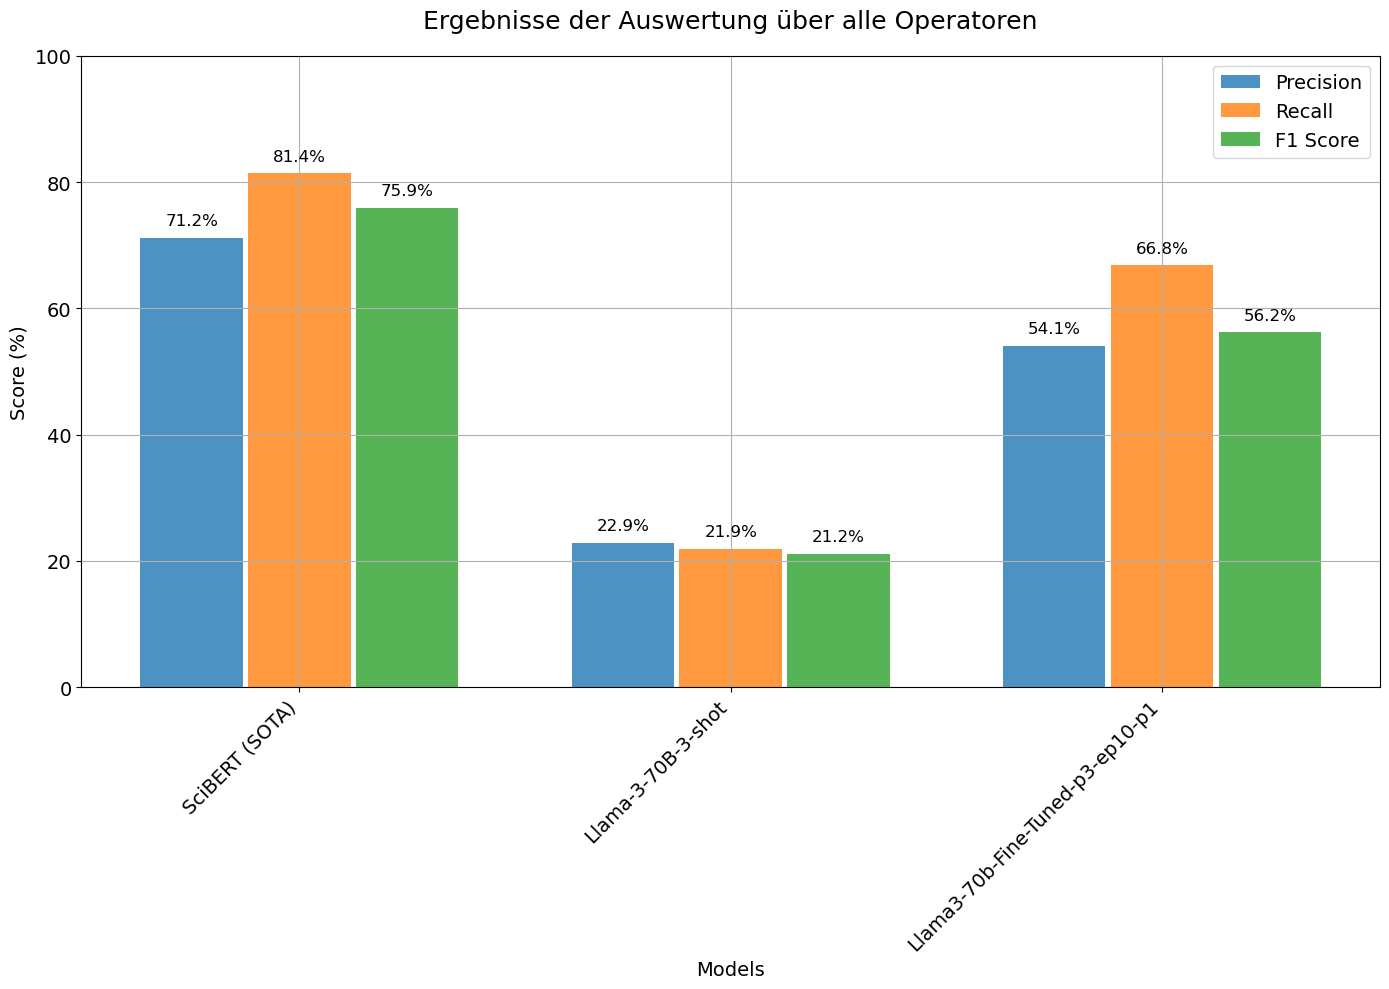

In [39]:
plot_avg_metrics(all_metrics)

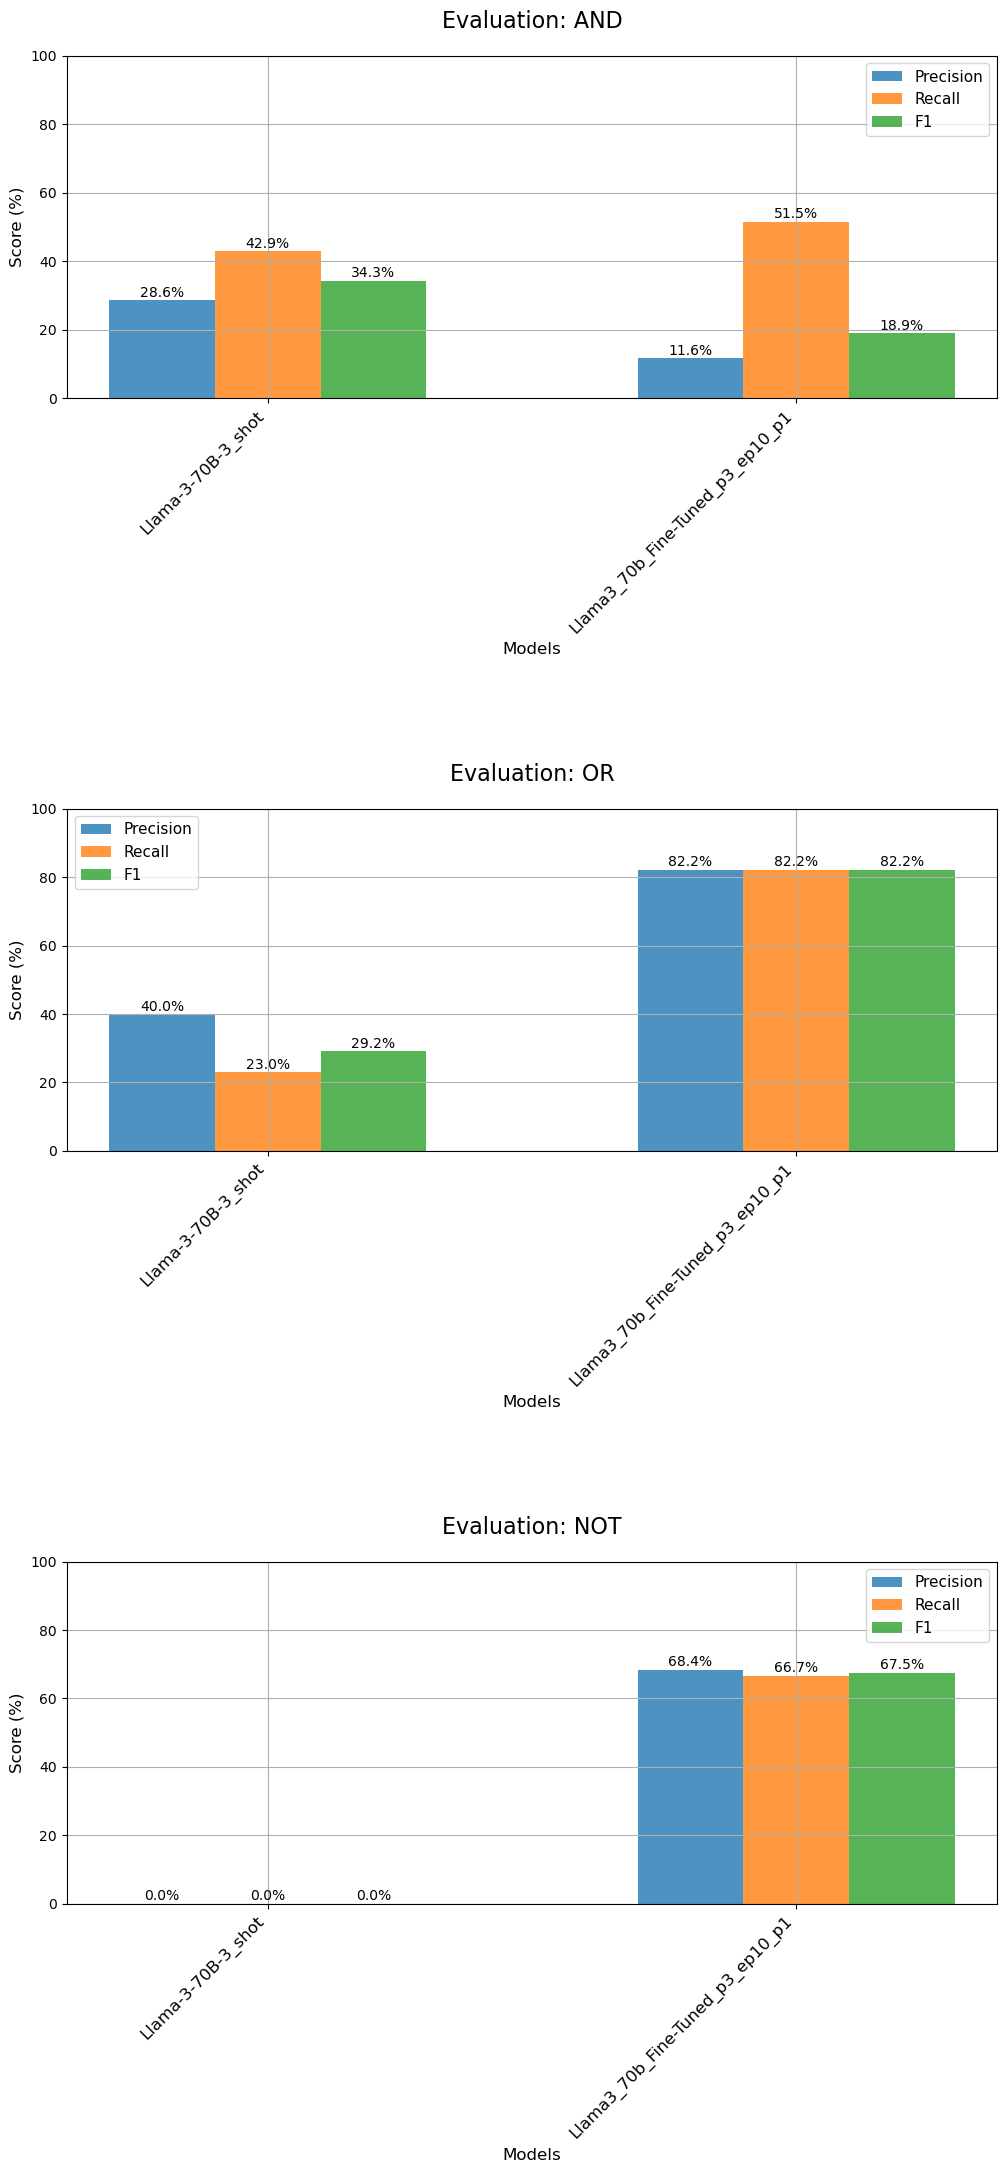

In [40]:
plot_operator_metrics(all_metrics)